# PyJAGS — AR(1) + Annual Cycle

Minimal example: fits an AR(1) model with a single annual harmonic to the regional trolley data, then computes DIC.

In [78]:
import numpy as np
import pandas as pd
import pyjags
from pyjags.dic import dic_samples
import matplotlib.pyplot as plt

## Load data

Same wide format as the R models: rows = regions, columns = weeks.

In [79]:
df = pd.read_csv('../data/wide_weekly_scaledPer10k.csv')
regions = df['Region'].values
y = df.drop(columns='Region').values  # shape: (n_regions, n_weeks)

n_region, n_weeks = y.shape
print(f"{n_region} regions, {n_weeks} weeks")

# time index for the harmonic (1-indexed to match R/JAGS convention)
t_idx = np.arange(1, n_weeks + 1)

6 regions, 151 weeks


## Model specification

This is the JAGS model string — identical to what you'd put in an `.Rmd`.

- AR(1) with global `phi`
- Annual harmonic: `beta1 * cos(2*pi*t/52) + beta2 * sin(2*pi*t/52)` per region
- Region-level intercept `alpha[i]` and precision `tau[i]`

In [80]:
MODEL_STRING = """
model {
  for (i in 1:I) {

    # --- Likelihood ---
    y[i,1] ~ dnorm(mu[i,1], tau[i])
    for (t in 2:T) {
      y[i,t] ~ dnorm(mu[i,t] + phi * (y[i,t-1] - mu[i,t-1]), tau[i])
    }

    # --- Mean function: intercept + annual harmonic ---
    for (t in 1:T) {
      mu[i,t] <- alpha[i]
                 + beta1[i] * cos(2 * 3.141593 * t / 52)
                 + beta2[i] * sin(2 * 3.141593 * t / 52)
    }

    # --- Priors (per region) ---
    alpha[i] ~ dnorm(0, 0.001)
    beta1[i] ~ dnorm(0, 0.001)
    beta2[i] ~ dnorm(0, 0.001)
    tau[i]   ~ dgamma(0.001, 0.001)
  }

  # --- Global AR(1) coefficient ---
  phi ~ dunif(-1, 1)
}
"""

## Fit the model

- 4 chains, 10k burn-in, 20k samples (same defaults as the R models)

In [81]:
# compile the model — pyjags takes the model string directly
# threads=2 with chains_per_thread=2 keeps DIC (pD) working
# (pD needs >=2 chains per thread)
model = pyjags.Model(
    code=MODEL_STRING,
    data=dict(y=y, I=n_region, T=n_weeks),
    chains=4,
    adapt=1000,
    threads=2,
    chains_per_thread=2,
)

# burn-in
model.sample(10000, vars=[])
print("Burn-in complete.")

adapting: iterations 4000 of 4000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 28998 of 40000, elapsed 0:00:09, remaining 0:00:03
sampling: iterations 40000 of 40000, elapsed 0:00:09, remaining 0:00:00
Burn-in complete.


In [82]:
# posterior samples
samples = model.sample(20000, vars=['alpha', 'beta1', 'beta2', 'phi', 'tau'])
print("Sampling complete.")
print("Keys:", list(samples.keys()))
print(f"phi shape: {samples['phi'].shape}  — (dims..., n_iter, n_chains)")

sampling: iterations 21292 of 80000, elapsed 0:00:06, remaining 0:00:18
sampling: iterations 47386 of 80000, elapsed 0:00:12, remaining 0:00:08
sampling: iterations 80000 of 80000, elapsed 0:00:15, remaining 0:00:00
Sampling complete.
Keys: ['phi', 'beta2', 'beta1', 'tau', 'alpha']
phi shape: (1, 20000, 4)  — (dims..., n_iter, n_chains)


## Quick posterior summary

In [83]:
def summarise(samples, var, labels=None):
    """Mean and 95% CI across all chains for a variable."""
    # pyjags returns shape (dim..., n_iter, n_chains)
    # flatten iterations and chains
    vals = samples[var].reshape(samples[var].shape[0], -1) if samples[var].ndim > 2 else samples[var].flatten()
    if vals.ndim == 1:
        vals = vals[np.newaxis, :]  # scalar param
    rows = []
    for i in range(vals.shape[0]):
        v = vals[i]
        label = labels[i] if labels is not None else f"{var}[{i+1}]"
        rows.append({
            'param': label,
            'mean': np.mean(v),
            'sd': np.std(v),
            '2.5%': np.percentile(v, 2.5),
            '97.5%': np.percentile(v, 97.5),
        })
    return pd.DataFrame(rows)

# phi (global)
display(summarise(samples, 'phi', labels=['phi']))

# alpha per region
display(summarise(samples, 'alpha', labels=[f'alpha[{r}]' for r in regions]))

,param,mean,sd,2.5%,97.5%
0,phi,0.560991,0.031358,0.50005,0.622622


,param,mean,sd,2.5%,97.5%
0,alpha[HSE Dublin and Midlands],3.821593,0.185027,3.454530,4.183270
1,alpha[HSE Dublin and North East],2.175581,0.119996,1.937522,2.408819
2,alpha[HSE Dublin and South East],2.868448,0.137262,2.597169,3.135688
3,alpha[HSE Mid West],7.966066,0.298629,7.378355,8.548924
4,alpha[HSE South West],4.269925,0.222937,3.826355,4.706658
5,alpha[HSE West and North West],6.185741,0.262112,5.668414,6.697575


## DIC

`dic_samples` is a standalone function in `pyjags.dic`, not a model method — same idea as `dic.samples()` in rjags.

In [84]:
dic = dic_samples(model, 20000)
print(dic)

updating: iterations 25312 of 80000, elapsed 0:00:07, remaining 0:00:16
updating: iterations 63652 of 80000, elapsed 0:00:13, remaining 0:00:03
updating: iterations 80000 of 80000, elapsed 0:00:16, remaining 0:00:00
Mean deviance: 5295.01
penalty: 51.21
Penalized deviance: 5346.23


## Trace plots with LOWESS smoother

ArviZ `plot_trace` doesn't have a built-in LOWESS like R's `traceplot(, smooth=TRUE)`.
We use `statsmodels.nonparametric.lowess` to overlay the same kind of trend line.

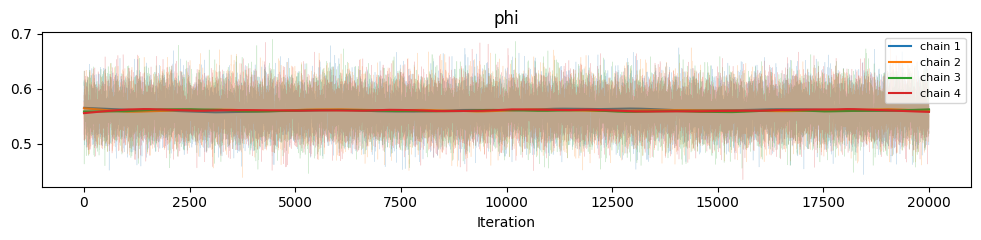

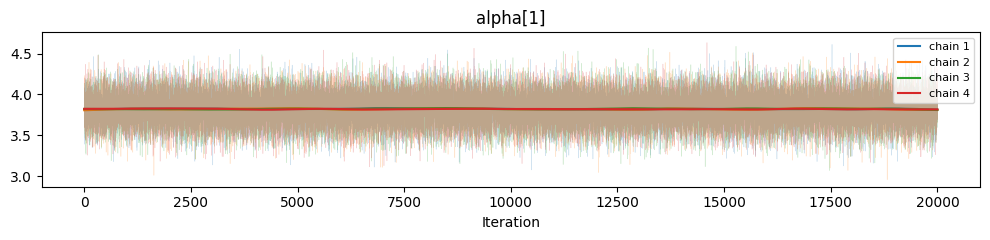

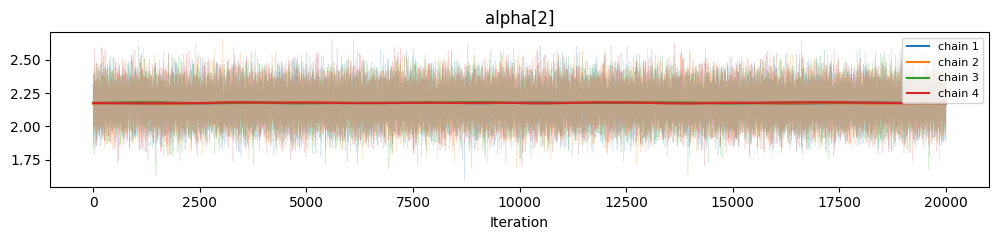

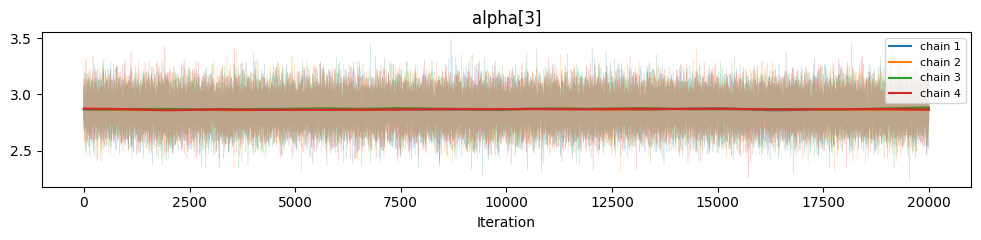

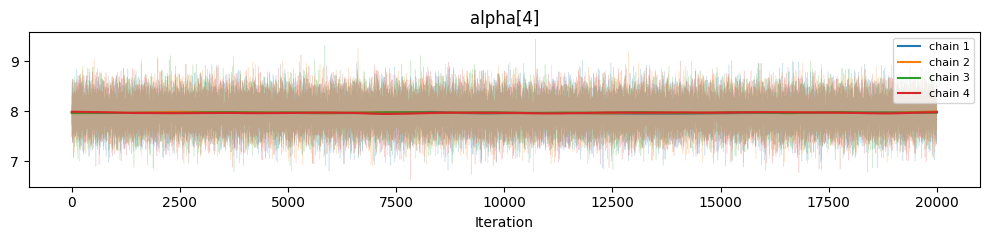

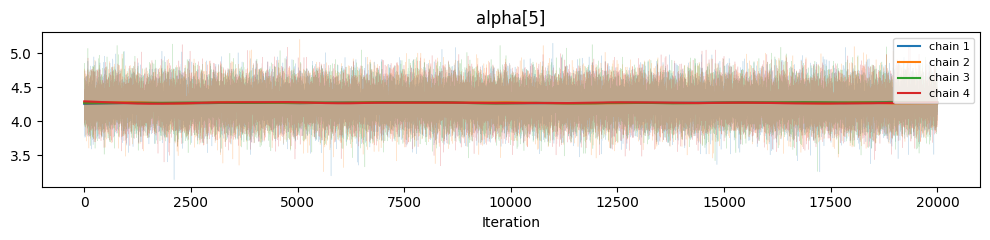

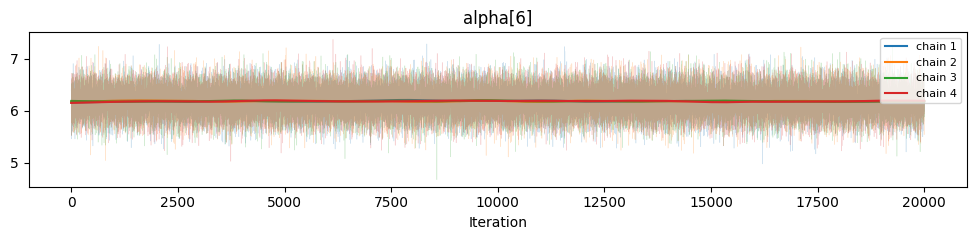

In [85]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from pyjags import from_pyjags
import arviz as az

idata = from_pyjags(samples)

def trace_with_lowess(samples, var_names, frac=0.1):
    """Trace plot with LOWESS smoother per chain, like R's traceplot(smooth=TRUE)."""
    for var in var_names:
        arr = samples[var]  # shape: (dim..., n_iter, n_chains)
        # flatten leading dims for indexing
        if arr.ndim == 3:
            n_elem, n_iter, n_chains = arr.shape
        else:
            arr = arr.reshape(1, *arr.shape)
            n_elem, n_iter, n_chains = arr.shape

        for elem in range(n_elem):
            label = f"{var}[{elem+1}]" if n_elem > 1 else var
            fig, ax = plt.subplots(figsize=(10, 2.5))
            x = np.arange(n_iter)
            for c in range(n_chains):
                vals = arr[elem, :, c]
                color = f'C{c}'
                ax.plot(x, vals, alpha=0.2, lw=0.4, color=color)
                # LOWESS trend — same idea as R's traceplot smooth
                smooth = lowess(vals, x, frac=frac, return_sorted=True)
                ax.plot(smooth[:, 0], smooth[:, 1], color=color, lw=1.5,
                        label=f'chain {c+1}')
            ax.set_title(label)
            ax.set_xlabel('Iteration')
            ax.legend(loc='upper right', fontsize=8)
            plt.tight_layout()
            plt.show()

trace_with_lowess(samples, ['phi', 'alpha'])

## Convergence diagnostics

`pyjags.diagnostics.convergence_report()` combines three things in one call:
- **R-hat** — the standard Gelman-Rubin statistic (from ArviZ)
- **ESS** — bulk and tail effective sample size (from ArviZ)
- **Chain divergence** — pairwise energy distance between chains (from Divergence). Catches problems R-hat misses because it compares entire distributions, not just moments.

First convert the samples to ArviZ format via `pyjags.from_pyjags()`.

In [86]:
from pyjags.diagnostics import convergence_report

# convergence_report works on scalar params — use it for phi
report = convergence_report(idata, var_names=['phi'])

print(f"Converged (all R-hat < 1.01): {report['converged']}")
print(f"Max R-hat:              {report['max_rhat']:.4f}")
print(f"Max chain divergence:   {report['max_chain_divergence']:.4f}")

Converged (all R-hat < 1.01): True
Max R-hat:              1.0002
Max chain divergence:   0.0000


In [87]:
# for array params (alpha, beta1, etc.) use ArviZ directly
rhat = az.rhat(idata)
ess_bulk = az.ess(idata, method="bulk")
ess_tail = az.ess(idata, method="tail")

diag_rows = []
for var in ['phi', 'alpha', 'beta1', 'beta2', 'tau']:
    r = rhat[var].values
    eb = ess_bulk[var].values
    et = ess_tail[var].values
    r, eb, et = np.atleast_1d(r), np.atleast_1d(eb), np.atleast_1d(et)
    for idx in range(len(r)):
        label = f"{var}[{idx+1}]" if len(r) > 1 else var
        diag_rows.append({
            'param': label,
            'R-hat': round(float(r[idx]), 4),
            'ESS_bulk': int(eb[idx]),
            'ESS_tail': int(et[idx]),
        })

df_diag = pd.DataFrame(diag_rows)
display(df_diag)

,param,R-hat,ESS_bulk,ESS_tail
0,phi,1.0002,33809,40443
1,alpha[1],1.0000,76237,75231
2,alpha[2],1.0000,77965,77959
3,alpha[3],1.0001,79196,76038
4,alpha[4],1.0000,78213,77857
5,alpha[5],1.0000,78496,78090
6,alpha[6],1.0000,78328,77210
7,beta1[1],1.0000,77657,77704
8,beta1[2],1.0000,78803,76605
9,beta1[3],1.0000,76973,75637
